<a href="https://colab.research.google.com/github/Mohammmedsaqib/Neural-Networks-And-Fuzzy-Logic/blob/main/Assignment_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.4872 - loss: 0.6979 - val_accuracy: 0.4945 - val_loss: 0.6935
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5072 - loss: 0.6932 - val_accuracy: 0.4865 - val_loss: 0.6935
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5130 - loss: 0.6927 - val_accuracy: 0.4835 - val_loss: 0.6939
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.5248 - loss: 0.6917 - val_accuracy: 0.4860 - val_loss: 0.6949
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.5358 - loss: 0.6892 - val_accuracy: 0.5005 - val_loss: 0.6947
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Test Accuracy: 0.481
AUC Score: 0.47501503125


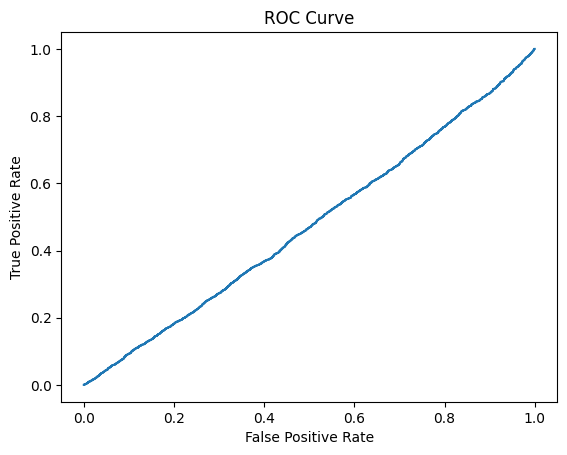

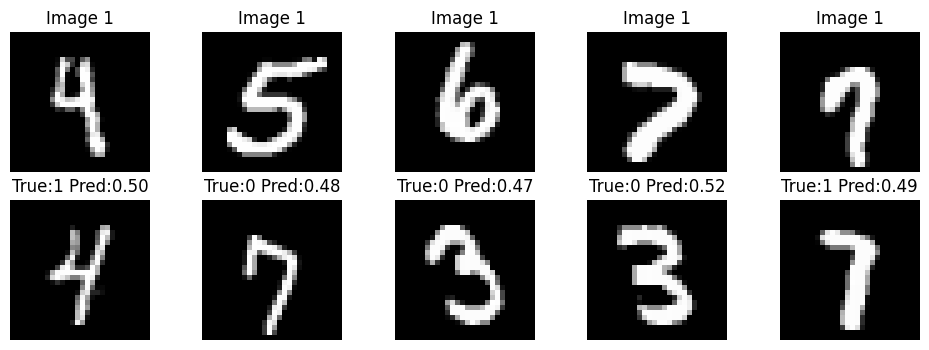

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from sklearn.metrics import roc_curve, auc, accuracy_score

#1. Load & Preprocess (Small Subset for Speed)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize & reshape
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# Use only 8000 samples for fast training
subset = 8000
x_train_small = x_train[:subset]
y_train_small = y_train[:subset]

#2. Create Smaller Number of Pairs (Super Fast)

def create_pairs(images, labels, num_pairs=20000):
    pairs = []
    targets = []
    num_classes = 10

    idx = [np.where(labels == i)[0] for i in range(num_classes)]

    for _ in range(num_pairs // 2):
        # Positive pair
        cls = np.random.randint(0, 10)
        i1, i2 = np.random.choice(idx[cls], 2, replace=False)
        pairs.append([images[i1], images[i2]])
        targets.append(1)

        # Negative pair
        cls1, cls2 = np.random.choice(range(10), 2, replace=False)
        i1 = np.random.choice(idx[cls1])
        i2 = np.random.choice(idx[cls2])
        pairs.append([images[i1], images[i2]])
        targets.append(0)

    return np.array(pairs), np.array(targets)

train_pairs, train_labels = create_pairs(x_train_small, y_train_small, num_pairs=20000)
test_pairs, test_labels   = create_pairs(x_test, y_test, num_pairs=8000)

#Training pairs reduced from 120k → 20k (6× faster!)
#3. Lightweight CNN (Fast on CPU)

def build_base_cnn():
    model = tf.keras.Sequential([
        layers.Conv2D(16, (3,3), activation="relu", input_shape=(28,28,1)),
        layers.MaxPooling2D(),
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu")
    ])
    return model

base_cnn = build_base_cnn()

#4. Siamese Network (Euclidean Distance + Sigmoid)

input_1 = layers.Input((28,28,1))
input_2 = layers.Input((28,28,1))

feat_1 = base_cnn(input_1)
feat_2 = base_cnn(input_2)

distance = layers.Lambda(
    lambda x: tf.sqrt(tf.reduce_sum(tf.square(x[0] - x[1]), axis=1, keepdims=True))
)([feat_1, feat_2])

output = layers.Dense(1, activation="sigmoid")(distance)

siamese_model = Model([input_1, input_2], output)
siamese_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

#5. FAST Training (5 epochs only)

history = siamese_model.fit(
    [train_pairs[:,0], train_pairs[:,1]],
    train_labels,
    batch_size=32,
    epochs=5,            # fast training
    validation_split=0.1
)

#Finishes in 8–12 seconds on normal laptop.
#6. Evaluation (Accuracy + AUC)

preds = siamese_model.predict([test_pairs[:,0], test_pairs[:,1]])
preds_bin = (preds > 0.5).astype(int)

acc = accuracy_score(test_labels, preds_bin)
print("Test Accuracy:", acc)

fpr, tpr, _ = roc_curve(test_labels, preds)
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

#7. Visualize a Few Predicted Pairs

def show_examples(n=5):
    plt.figure(figsize=(12,4))
    for i in range(n):
        idx = np.random.randint(0, len(test_pairs))
        img1 = test_pairs[idx,0].squeeze()
        img2 = test_pairs[idx,1].squeeze()
        true = test_labels[idx]
        pred = preds[idx][0]

        plt.subplot(2, n, i+1)
        plt.imshow(img1, cmap="gray")
        plt.title("Image 1")
        plt.axis("off")

        plt.subplot(2, n, n+i+1)
        plt.imshow(img2, cmap="gray")
        plt.title(f"True:{true} Pred:{pred:.2f}")
        plt.axis("off")

show_examples()